# Class-Based Audio Plotting Suite

This notebook uses separate classes for loading measurements, validating channel names, styling axes, drawing series, choosing subplot layouts, and producing each graph type.

It works with any CSV that has one `Frequency (Hz)` column and one or more channel columns.

## Plot capabilities

1. **One subplot per channel:** six channels displayed in a shared figure.
2. **All channels together:** every channel overlaid on one set of axes.
3. **One requested channel:** only the chosen channel.

Customize a plot by changing `PlotConfig`: plot kind, size, colors, scales, labels, limits, grid, and line/marker settings.

In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Configuration and data-model classes

`PlotConfig` keeps all visual choices in one object. `AudioMeasurement` loads and validates one CSV. `MeasurementCatalog` caches measurements so a file is loaded once even if you make several graphs from it.

In [2]:
@dataclass
class PlotConfig:
    plot_kind: str = "line"  # "line", "scatter", or "line_scatter"
    figure_size: tuple[float, float] = (11, 6)
    color_map: str = "tab10"
    x_scale: str = "log"
    y_scale: str = "linear"
    x_label: str = "Frequency (Hz)"
    y_label: str = "Level (dBSPL)"
    title: Optional[str] = None
    x_limits: Optional[tuple[float, float]] = None
    y_limits: Optional[tuple[float, float]] = None
    show_grid: bool = True
    line_width: float = 1.8
    marker_size: float = 18
    alpha: float = 0.9


class AudioMeasurement:
    """Load one frequency-response CSV and expose its channel columns."""

    frequency_column = "Frequency (Hz)"

    def __init__(self, csv_path: str | Path):
        self.path = Path(csv_path)
        self.data = pd.read_csv(self.path)
        self._validate()

    def _validate(self):
        if self.frequency_column not in self.data.columns:
            raise ValueError(f"{self.path.name} needs a '{self.frequency_column}' column.")
        if not self.channel_columns:
            raise ValueError(f"{self.path.name} needs at least one channel column.")
        self.data[self.frequency_column] = pd.to_numeric(
            self.data[self.frequency_column], errors="raise"
        )
        for channel in self.channel_columns:
            self.data[channel] = pd.to_numeric(self.data[channel], errors="raise")

    @property
    def channel_columns(self) -> list[str]:
        return [column for column in self.data.columns if column != self.frequency_column]

    @property
    def name(self) -> str:
        return self.path.stem.upper()


class MeasurementCatalog:
    """Cache measurements by path so repeated plots do not reload files."""

    def __init__(self):
        self._measurements: dict[Path, AudioMeasurement] = {}

    def get(self, csv_path: str | Path) -> AudioMeasurement:
        path = Path(csv_path)
        if path not in self._measurements:
            self._measurements[path] = AudioMeasurement(path)
        return self._measurements[path]

## Support classes

`ChannelSelector` validates requested channel names. `AxisStyler` applies the common axis choices. `SeriesDrawer` is the only class that knows how to draw line, scatter, and line-plus-scatter series. `SubplotLayout` calculates a grid large enough for every requested channel.

In [3]:
class ChannelSelector:
    def __init__(self, measurement: AudioMeasurement):
        self.measurement = measurement

    def one(self, channel: str) -> str:
        if channel not in self.measurement.channel_columns:
            choices = ", ".join(self.measurement.channel_columns)
            raise ValueError(f"Unknown channel '{channel}'. Choose one of: {choices}")
        return channel

    def many(self, channels: Optional[list[str]] = None) -> list[str]:
        selected = self.measurement.channel_columns if channels is None else channels
        return [self.one(channel) for channel in selected]


class AxisStyler:
    def __init__(self, config: PlotConfig):
        self.config = config

    def apply(self, ax, title: str):
        ax.set_xscale(self.config.x_scale)
        ax.set_yscale(self.config.y_scale)
        ax.set(xlabel=self.config.x_label, ylabel=self.config.y_label, title=title)
        if self.config.x_limits is not None:
            ax.set_xlim(self.config.x_limits)
        if self.config.y_limits is not None:
            ax.set_ylim(self.config.y_limits)
        if self.config.show_grid:
            ax.grid(True, which="both", alpha=0.3)


class SeriesDrawer:
    def __init__(self, config: PlotConfig):
        self.config = config

    def draw(self, ax, frequency, values, label: str, color):
        line_settings = {
            "label": label,
            "color": color,
            "linewidth": self.config.line_width,
            "alpha": self.config.alpha,
        }
        scatter_settings = {
            "label": label,
            "color": color,
            "s": self.config.marker_size,
            "alpha": self.config.alpha,
        }

        if self.config.plot_kind == "line":
            ax.plot(frequency, values, **line_settings)
        elif self.config.plot_kind == "scatter":
            ax.scatter(frequency, values, **scatter_settings)
        elif self.config.plot_kind == "line_scatter":
            ax.plot(frequency, values, **line_settings)
            scatter_settings.pop("label")
            ax.scatter(frequency, values, **scatter_settings)
        else:
            raise ValueError("plot_kind must be 'line', 'scatter', or 'line_scatter'.")


@dataclass
class SubplotLayout:
    columns: int = 3

    def shape_for(self, item_count: int) -> tuple[int, int]:
        if self.columns < 1:
            raise ValueError("columns must be at least 1.")
        return math.ceil(item_count / self.columns), self.columns

## Plotter classes

Each plotter has one responsibility. The three public plotters below correspond directly to the three requested graph types.

In [4]:
import math


class BasePlotter:
    def __init__(self, measurement: AudioMeasurement, config: PlotConfig):
        self.measurement = measurement
        self.config = config
        self.selector = ChannelSelector(measurement)
        self.styler = AxisStyler(config)
        self.drawer = SeriesDrawer(config)
        self.colors = plt.get_cmap(config.color_map)

    def _frequency(self):
        return self.measurement.data[self.measurement.frequency_column]

    def _color(self, index: int):
        return self.colors(index % self.colors.N)


class AllChannelsPlotter(BasePlotter):
    """Overlay selected channels on one set of axes."""

    def plot(self, channels: Optional[list[str]] = None):
        selected = self.selector.many(channels)
        fig, ax = plt.subplots(figsize=self.config.figure_size)

        for index, channel in enumerate(selected):
            self.drawer.draw(
                ax,
                self._frequency(),
                self.measurement.data[channel],
                channel,
                self._color(index),
            )

        title = self.config.title or f"{self.measurement.name}: All Channels"
        self.styler.apply(ax, title)
        ax.legend()
        fig.tight_layout()
        return fig, ax


class ChannelSubplotPlotter(BasePlotter):
    """Put each selected channel in its own subplot within one figure."""

    def plot(self, channels: Optional[list[str]] = None, columns: int = 3):
        selected = self.selector.many(channels)
        rows, columns = SubplotLayout(columns).shape_for(len(selected))
        figure_size = (self.config.figure_size[0], self.config.figure_size[1] * rows)
        fig, axes = plt.subplots(rows, columns, figsize=figure_size, squeeze=False)
        flat_axes = axes.ravel()

        for index, channel in enumerate(selected):
            ax = flat_axes[index]
            self.drawer.draw(
                ax,
                self._frequency(),
                self.measurement.data[channel],
                channel,
                self._color(index),
            )
            self.styler.apply(ax, channel)

        for ax in flat_axes[len(selected):]:
            ax.set_visible(False)

        title = self.config.title or f"{self.measurement.name}: One Subplot per Channel"
        fig.suptitle(title, fontsize=16)
        fig.tight_layout()
        return fig, axes


class SingleChannelPlotter(BasePlotter):
    """Plot one requested channel."""

    def plot(self, channel: str):
        channel = self.selector.one(channel)
        fig, ax = plt.subplots(figsize=self.config.figure_size)
        self.drawer.draw(
            ax,
            self._frequency(),
            self.measurement.data[channel],
            channel,
            self._color(self.measurement.channel_columns.index(channel)),
        )
        title = self.config.title or f"{self.measurement.name}: {channel}"
        self.styler.apply(ax, title)
        ax.legend()
        fig.tight_layout()
        return fig, ax

## One class to use from now on

`AudioPlotSuite` is the convenient front door. It owns the measurement and creates the specialized plotter classes for you.

In [ ]:
class AudioPlotSuite:
    def __init__(self, csv_path: str | Path, config: Optional[PlotConfig] = None, catalog=None):
        self.catalog = catalog or MeasurementCatalog()
        self.measurement = self.catalog.get(csv_path)
        
        self.config = config or PlotConfig()

    @property
    def channels(self) -> list[str]:
        return self.measurement.channel_columns

    def all_channels(self, channels: Optional[list[str]] = None):
        return AllChannelsPlotter(self.measurement, self.config).plot(channels)

    def subplots_by_channel(self, channels: Optional[list[str]] = None, columns: int = 3):
        return ChannelSubplotPlotter(self.measurement, self.config).plot(channels, columns)

    def channel(self, channel_name: str):
        return SingleChannelPlotter(self.measurement, self.config).plot(channel_name)

## Use the suite with `gain.csv`

All three requested plot types are shown below. Edit the configuration values to customize the appearance before rerunning the examples.

In [6]:
gain_config = PlotConfig(
    plot_kind="line_scatter",
    figure_size=(11, 4),
    y_label="Gain (dBSPL)",
    y_limits=(82, 98),
    color_map="tab10",
)

gain_plots = AudioPlotSuite("data/gain.csv", config=gain_config)
gain_plots.channels

['Channel 1 (dBSPL)',
 'Channel 2 (dBSPL)',
 'Channel 3 (dBSPL)',
 'Channel 4 (dBSPL)',
 'Channel 5 (dBSPL)',
 'Channel 6 (dBSPL)']

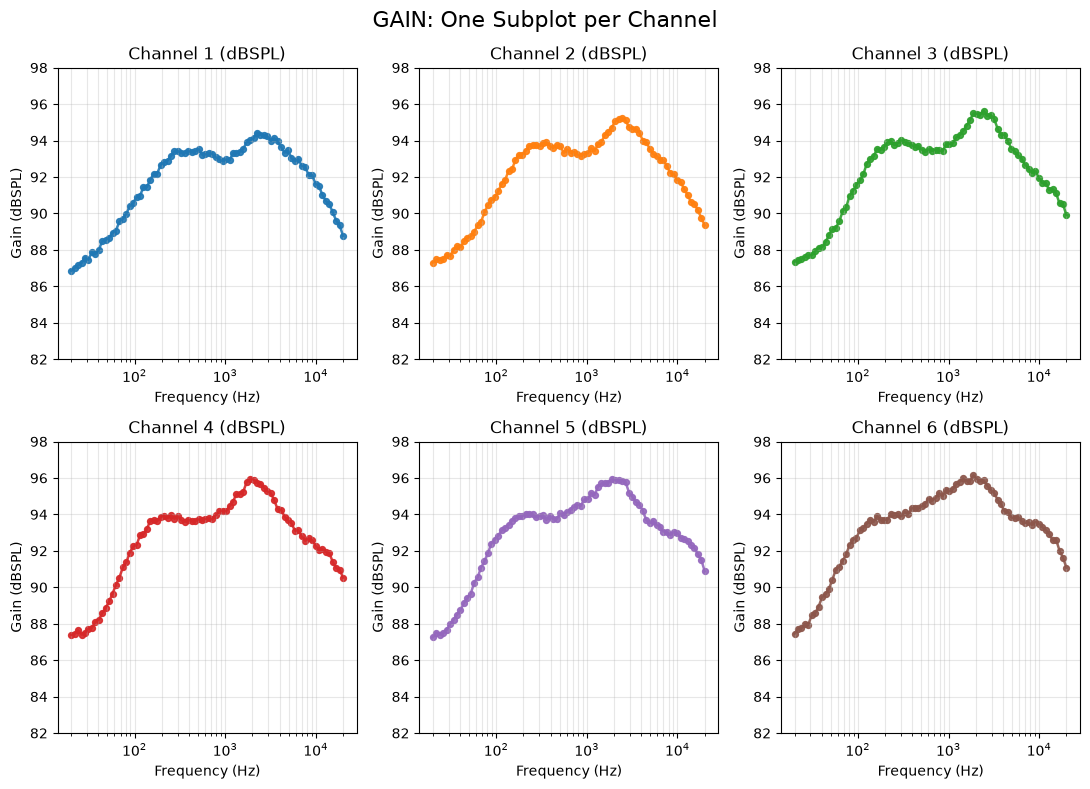

In [7]:
# 1. Every gain channel in its own subplot, all inside one figure.
gain_plots.subplots_by_channel(columns=3)
plt.show()

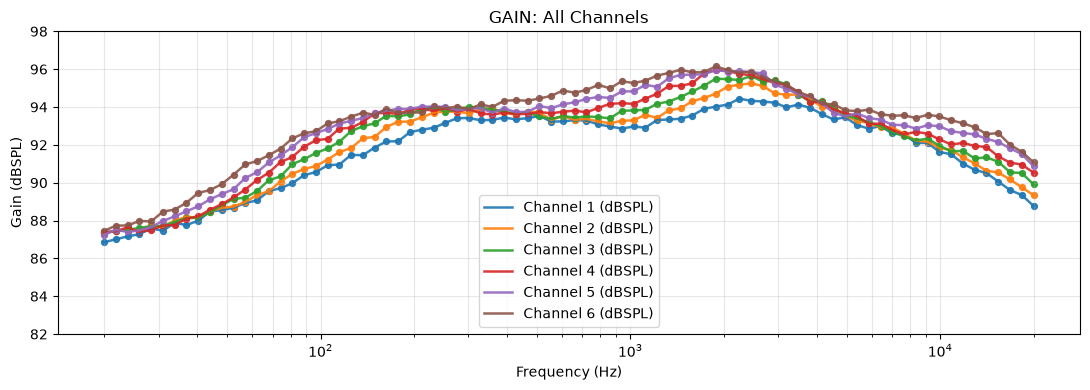

In [8]:
# 2. Every gain channel together on one graph.
gain_plots.all_channels()
plt.show()

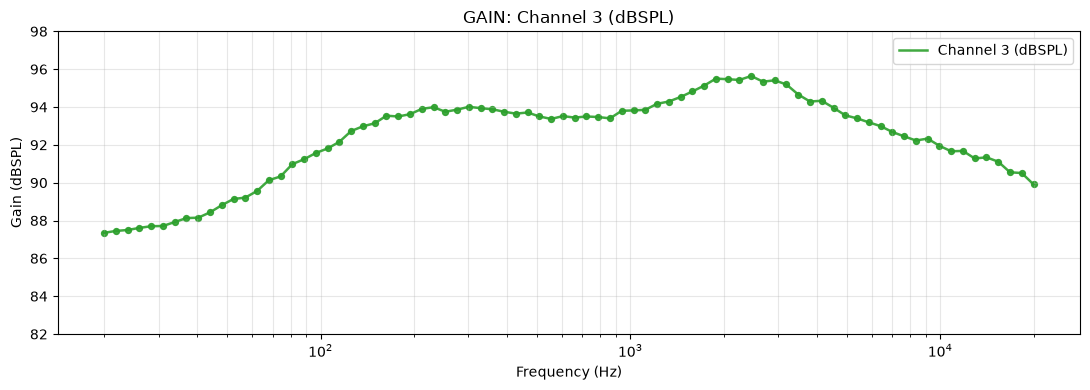

In [9]:
# 3. Only the requested channel.
gain_plots.channel("Channel 3 (dBSPL)")
plt.show()

## Reuse the same classes with `thd.csv`

No class definitions need to change. Create a different configuration and pass in the other CSV.

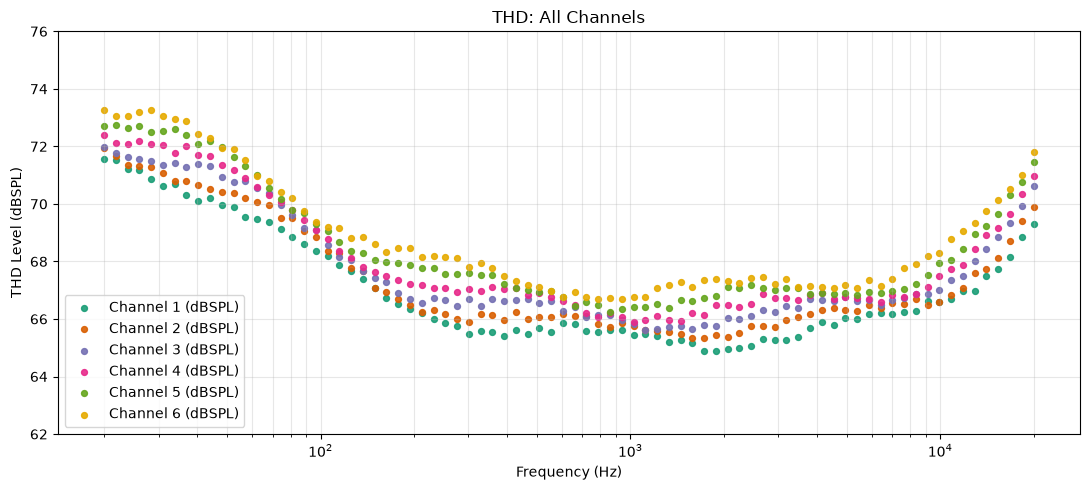

In [11]:
thd_config = PlotConfig(
    plot_kind="scatter",
    figure_size=(11, 5),
    y_label="THD Level (dBSPL)",
    y_limits=(62, 76),
    color_map="Dark2",
)

thd_plots = AudioPlotSuite("data/thd.csv", config=thd_config)
thd_plots.all_channels()
plt.show()

## Customization reference

```python
# Plot only a subset on one graph.
gain_plots.all_channels([
    "Channel 1 (dBSPL)",
    "Channel 6 (dBSPL)",
])

# Give every channel a subplot in two columns instead of three.
gain_plots.subplots_by_channel(columns=2)

# Change configuration before creating a new suite.
custom_config = PlotConfig(
    plot_kind="line",
    x_scale="linear",
    y_limits=(85, 100),
    show_grid=False,
    line_width=3,
)
custom_plots = AudioPlotSuite("data/gain.csv", custom_config)
custom_plots.channel("Channel 1 (dBSPL)")
```